# Physical AI 基礎編 知能ロボティクス講座 2026 Spring 第6回 演習資料

## 汚れた bag から、学習可能なデータセットを納品せよ

> ✅ **ローカル全セル実行・検証済み**（解答版・Linux / Python 3.12・2026-07-22）。
> Colab 実機の Step 6 障害（transformers 5.4 競合・動画コーデック）に対策済み（互換ガード / yuv420p 強制）。
> 当日ランタイムでの最終確認は別途実施予定。

**ミッション**：先輩たちがテレオペで集めた生データ（bag 16 本）が渡されました。中身は本物の人間の操作データです。学習チームは「LeRobotDataset 形式で、学習して大丈夫なものだけ」を待っています。ただし、講義で学んだ種類の問題がいくつか混ざっています。

- **授業内ゴール**：Step 3 の「動くデータセット」＋判断表に 1 行以上
- 最後に Step 5 で、キュレーションの質が方策の成功率をどれだけ変えるか、答え合わせを見せます
- 時間が余った人・もっと遊びたい人向けに、最後に**発展課題**があります（提出はありません）

### はじめに（形式と Colab の作法）

今回は講座で初めての「**穴埋め形式**」です。`# TODO` のセルを自分で埋めて進めます。

- 各 TODO の直後に**解答セル**（フォームモードで折りたたみ）があります。詰まったら開いて構いません
- 各 Step の最後に **checkpoint セル**があります。途中が動かなくても checkpoint を実行すれば次の Step に追いつけます
- 講師の号令があったら checkpoint で足並みを揃えます

Colab の作法（3 行）：

1. ランタイムは **CPU のままで OK** です（GPU は不要です）
2. 最初に「ファイル → ドライブにコピーを保存」してから進めてください
3. 「このノートブックは Google が作成したものではありません」の警告は「このまま実行」を選択してください

In [ ]:
# セル 0-1: ライブラリのインストール（Colab のみ実行されます。5分ほどかかります）
import sys

if "google.colab" in sys.modules:
    # バージョン固定の理由:
    #   rosbags>=0.10.9 : MCAP 形式の bag 読み込みは 0.10.9 以降で安定
    #   lerobot==0.5.1  : 第1回と同じ版に固定(APIが版間で大きく変わるため)
    #   robosuite/mujoco: Step 5 のライブ rollout 用(robosuite 1.5系 + mujoco 3.9以下)
    #   transformers==5.3.0 : lerobot 0.5.1 が extras で指定している版。5.4.0 で PretrainedConfig が
    #        dataclass 化され、lerobot 0.5.1 の GR00TN15Config が import 時に TypeError になる。
    #        lerobot は transformers を base 依存に持たないため、固定しないと Colab 側の新しい版が残る。
    #        ACT は transformers を使わないので本編・Step5・Step6 に副作用はない。
    # 注意: robomimic は絶対に入れないでください。robomimic は diffusers==0.11.1 固定で、
    #        lerobot の diffusers>=0.27.2 と衝突し、環境が壊れます。
    !pip install -q "rosbags>=0.10.9" "lerobot==0.5.1" "transformers==5.3.0"                     "robosuite>=1.5,<2" "mujoco<3.10"

    # numpy が入れ替わった場合はランタイム再起動が必要です(再起動後にこのセルからやり直し)
    import importlib
    import numpy
    importlib.reload(numpy)
print("install: OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 128.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 132.9 MB/s eta 0:00:0

/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [ ]:
# セル 0-2: 補助モジュールと演習データの取得(本編は約 65 MB・1〜2 分)
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from huggingface_hub import hf_hub_download
    # 毎回 HF から最新を取得(force_download)。utils を更新したら再アップロードするだけで
    # 追随でき、ノートブックと utils.py の版ズレを防げます。
    for _f in ("utils.py", "utils_rollout.py"):
        hf_hub_download("Adwaver4157/pai2026-lecture6-data", _f, repo_type="dataset", local_dir=".", force_download=True)

import utils

# lerobot × transformers の互換ガード（Colab の新しい transformers を無害化し、
# lerobot.policies を一度通す）。ここで失敗すれば setup 内に被害を閉じ込められます。
utils.ensure_lerobot_importable()

# 本編(Step 0〜4)で使う約 65 MB だけを取得します。
# 重い学習済みモデル(Step 5 のライブ rollout / 発展 Step 6)は、
# それを使うセルの中で必要になったときに自動で追加ダウンロードされます。
DATA = utils.fetch_data()
print("データの場所:", DATA.resolve())

utils.py:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

utils_rollout.py:   0%|          | 0.00/5.64k [00:00<?, ?B/s]

transformers: 5.3.0
lerobot.policies import OK


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 63 files:   0%|          | 0/63 [00:00<?, ?it/s]

データの場所: /content/lecture6_data


In [ ]:
# セル 0-3: セットアップの self-check
utils.check_step0()

✅ bag 件数: 16 件（期待: 16 件）
✅ 合計サイズ: 44.2 MB（期待: 30〜70 MB）
✅ rosbags: version 0.11.3（期待: >= 0.10）
環境: lerobot 0.5.1 / transformers 5.3.0 / torch 2.10.0 / robosuite 1.5.1 / MUJOCO_GL=(未設定)

Step 0 完了です。


## Step 1: Inspect — 生データの解剖(5 分)

*講義スライド「生データの解剖学」対応*

まず、渡された bag の中身を**信じずに**自分の目で確かめます。トピック構成・実効周波数・タイムスタンプの姿の 3 点です。

In [ ]:
# セル 1-1(与えるコード): 全 bag のトピック表
# 4 トピック: カメラ2(20Hz) / 関節状態(50Hz) / テレオペ指令(20Hz)
rate_df = utils.topic_table()
rate_df.pivot_table(index="bag", columns="topic", values="rate_hz")

topic,/cam_agentview/compressed,/cam_wrist/compressed,/joint_states,/leader/action
bag,,,,
ep_000,19.8,20.0,48.7,20.0
ep_001,20.0,19.9,50.1,20.1
ep_002,20.0,19.9,48.1,20.0
ep_003,20.0,19.8,49.3,20.2
ep_004,19.9,20.0,49.7,20.0
ep_005,19.9,20.0,50.6,20.1
ep_006,20.0,19.9,50.3,20.0
ep_007,19.9,20.0,49.8,19.8
ep_008,19.8,19.9,52.1,19.9


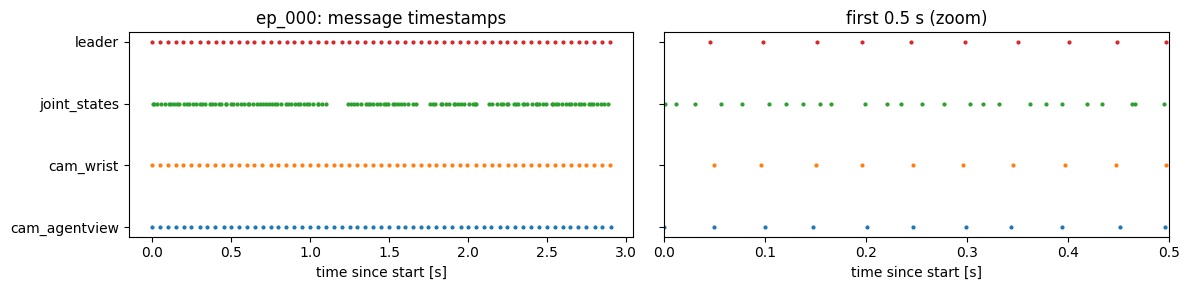

In [ ]:
# セル 1-2【TODO-1】: 1 本の bag のタイムスタンプを散布図にする
# ヒント: topics[トピック名]["stamp"] が header.stamp(秒)の配列です
import matplotlib.pyplot as plt

bag = utils.list_bags()[0]          # ep_000
topics = utils.read_bag(bag)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, xlim in zip(axes, [None, 0.5]):
    for row, topic in enumerate(utils.ALL_TOPICS):
        # ---- TODO ここから(2 行): stamp 配列を取り出し、エピソード先頭からの相対時刻にする
        stamps = topics[topic]["stamp"]
        t_rel = stamps - topics[utils.TOPIC_CAM_AGENT]["stamp"][0]
        # ---- TODO ここまで
        ax.scatter(t_rel, [row] * len(t_rel), s=4, label=topic.split("/")[1])
    ax.set_yticks(range(4), [t.split("/")[1] for t in utils.ALL_TOPICS])
    ax.set_xlabel("time since start [s]")
    if xlim:
        ax.set_xlim(0, xlim)
        ax.set_title("first 0.5 s (zoom)")
axes[0].set_title(f"{bag.name}: message timestamps")
plt.tight_layout(); plt.show()

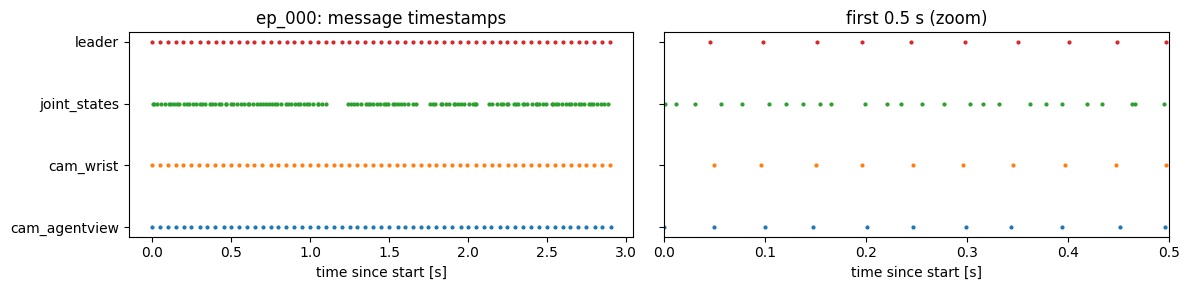

In [ ]:
#@title ▶ 解答 1(詰まったら開いて実行してください) { display-mode: "form" }
import matplotlib.pyplot as plt

bag = utils.list_bags()[0]
topics = utils.read_bag(bag)
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, xlim in zip(axes, [None, 0.5]):
    for row, topic in enumerate(utils.ALL_TOPICS):
        stamps = topics[topic]["stamp"]
        t_rel = stamps - topics[utils.TOPIC_CAM_AGENT]["stamp"][0]
        ax.scatter(t_rel, [row] * len(t_rel), s=4)
    ax.set_yticks(range(4), [t.split("/")[1] for t in utils.ALL_TOPICS])
    ax.set_xlabel("time since start [s]")
    if xlim:
        ax.set_xlim(0, xlim); ax.set_title("first 0.5 s (zoom)")
axes[0].set_title(f"{bag.name}: message timestamps")
plt.tight_layout(); plt.show()

,/cam_agentview/compressed,/cam_wrist/compressed,/joint_states,/leader/action
bag,,,,
ep_000,-9.4,-8.6,-2.4,-1.9
ep_001,-9.3,-9.6,-1.9,-2.0
ep_002,-9.7,-10.1,-1.4,-1.4
ep_003,-8.8,-10.8,-1.2,-2.2
ep_004,-9.7,-10.0,-2.3,-1.9
ep_005,-8.8,-9.0,-2.4,-2.0
ep_006,-10.5,-10.4,348.2,-2.0
ep_007,-10.3,-9.8,-1.8,-2.3
ep_008,-8.5,-8.9,-2.8,-2.8


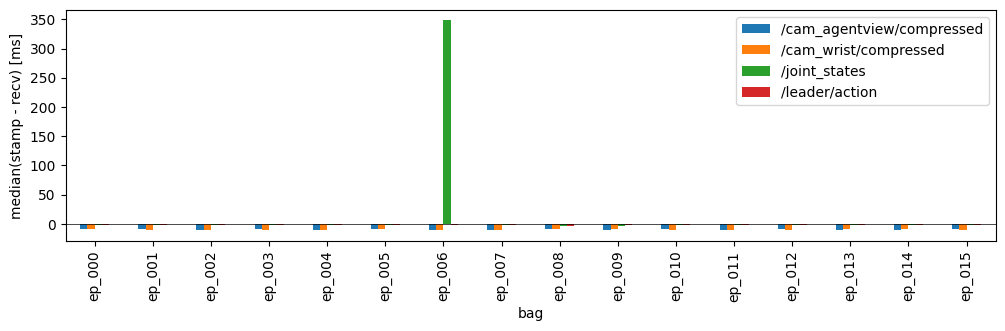

In [ ]:
# セル 1-3(与えるコード): bag別・トピック別の median(stamp − 受信時刻) [ms]
# 「stamp はデバイスが打った時刻、受信時刻は記録PCが受け取った時刻」——正常なら
# stamp の方がわずかに古い(= −数 ms)はずです。大きく正(未来)にずれる bag は?
latency_df = utils.latency_table()
ax = latency_df.plot.bar(figsize=(12, 3), ylabel="median(stamp - recv) [ms]")
ax.axhline(0, color="k", lw=0.5)
latency_df.round(1)

### 気づいたことをメモ(1 行でOK)

> bag ____ が変。根拠: Δt 分布 / レイテンシ / 実効 Hz のどれか →

*(ダブルクリックして記入してください)*

In [ ]:
# セル 1-5: Step 1 の self-check
utils.check_step1(rate_df, latency_df)

✅ カメラ実効レート: 20Hz ±10% に 16/16 本
✅ 関節実効レート: 50Hz ±10% に 16/16 本
✅ レイテンシ異常 bag: 1 本（期待: ちょうど 1 本、median(stamp−受信時刻) が +300ms 超）

Step 1 完了です。


## Step 2: Sync — ApproximateTime を自分で書く(8 分)

*講義スライド「時刻同期」対応*

カメラのフレーム時刻を基準(マスター)にして、各トピックから「一番近い時刻のメッセージ」を拾います。ROS 2 の `ApproximateTimeSynchronizer` がやっていることの素朴版です。

- カメラ(wrist)・指令: **最近傍マッチ**(許容窓 slop 以内になければそのフレームは捨てる)
- 関節(50Hz で密): **線形補間**(`np.interp`)——ただし**範囲外は捨てる**(端点クランプの罠)

In [ ]:
# セル 2-1【TODO-2】: 最近傍マッチ nearest() を完成させる(本丸です)
import numpy as np

def nearest(stamps, t, slop):
    """昇順の stamps から t に最も近い時刻のインデックスを返す。
    |stamps[i] - t| > slop なら None(マッチなし)。"""
    # ---- TODO ここから(3 行): searchsorted で挿入点を求め、前後 2 候補の近い方を選ぶ
    i = np.searchsorted(stamps, t)
    cands = [j for j in (i - 1, i) if 0 <= j < len(stamps)]
    best = min(cands, key=lambda j: abs(stamps[j] - t))
    # ---- TODO ここまで
    return best if abs(stamps[best] - t) <= slop else None
    # 別解: np.argmin(np.abs(stamps - t)) の 1 行でも正解です(データ量が多いと遅い)


def sync_bag(topics, slop=0.020):
    """agentview のフレーム時刻を基準に全トピックを同期する。"""
    cam = topics[utils.TOPIC_CAM_AGENT]
    jnt = topics[utils.TOPIC_JOINTS]
    rows = {"t": [], "state": [], "action": [], "cam_idx": [], "wrist_idx": []}
    for i, t in enumerate(cam["stamp"]):
        iw = nearest(topics[utils.TOPIC_CAM_WRIST]["stamp"], t, slop)
        ia = nearest(topics[utils.TOPIC_ACTION]["stamp"], t, slop)   # TODO(1 行): 指令も同様に
        if iw is None or ia is None:
            continue
        # 関節は補間——ただし範囲外なら捨てる(与えるコード。D1 で端点クランプが起きる罠に対処済み)
        if not (jnt["stamp"][0] <= t <= jnt["stamp"][-1]):
            continue
        state = np.array([np.interp(t, jnt["stamp"], jnt["val"][:, j]) for j in range(7)])
        rows["t"].append(t); rows["state"].append(state)
        rows["action"].append(topics[utils.TOPIC_ACTION]["val"][ia])
        rows["cam_idx"].append(i); rows["wrist_idx"].append(iw)
    return {k: np.asarray(v) for k, v in rows.items()}


topics = utils.read_bag(utils.list_bags()[0])
synced = sync_bag(topics)
print(f"採用フレーム数: {len(synced['t'])}(カメラ {len(topics[utils.TOPIC_CAM_AGENT]['stamp'])} フレーム中)")

採用フレーム数: 57(カメラ 59 フレーム中)


In [ ]:
#@title ▶ 解答 2(詰まったら開いて実行してください) { display-mode: "form" }
import numpy as np

def nearest(stamps, t, slop):
    i = np.searchsorted(stamps, t)
    cands = [j for j in (i - 1, i) if 0 <= j < len(stamps)]
    best = min(cands, key=lambda j: abs(stamps[j] - t))
    return best if abs(stamps[best] - t) <= slop else None

def sync_bag(topics, slop=0.020):
    cam = topics[utils.TOPIC_CAM_AGENT]
    jnt = topics[utils.TOPIC_JOINTS]
    rows = {"t": [], "state": [], "action": [], "cam_idx": [], "wrist_idx": []}
    for i, t in enumerate(cam["stamp"]):
        iw = nearest(topics[utils.TOPIC_CAM_WRIST]["stamp"], t, slop)
        ia = nearest(topics[utils.TOPIC_ACTION]["stamp"], t, slop)
        if iw is None or ia is None:
            continue
        if not (jnt["stamp"][0] <= t <= jnt["stamp"][-1]):
            continue
        state = np.array([np.interp(t, jnt["stamp"], jnt["val"][:, j]) for j in range(7)])
        rows["t"].append(t); rows["state"].append(state)
        rows["action"].append(topics[utils.TOPIC_ACTION]["val"][ia])
        rows["cam_idx"].append(i); rows["wrist_idx"].append(iw)
    return {k: np.asarray(v) for k, v in rows.items()}

topics = utils.read_bag(utils.list_bags()[0])
synced = sync_bag(topics)
print(f"採用フレーム数: {len(synced['t'])}")

採用フレーム数: 57


In [ ]:
# セル 2-2: Step 2 の self-check(実装差 ±3 フレームまで許容します)
utils.check_step2("ep_000", len(synced["t"]))

✅ ep_000 の採用フレーム数: 57 フレーム（期待: 57 ±3 フレーム）

Step 2 完了です。


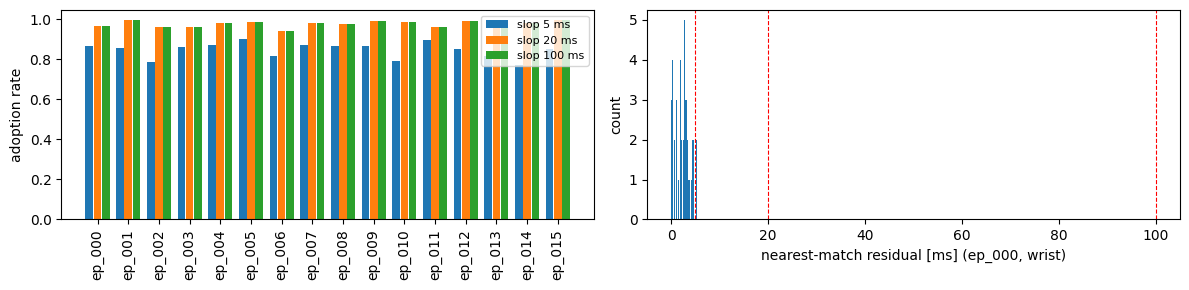

観察: slop 5→20→100 ms で採用率はどう変わりましたか?
      レイテンシ異常だった bag の採用率は…下がっていますか?(→ 下がりません!)


In [ ]:
# セル 2-3【TODO-3】: slop を {5, 20, 100} ms で掃引して採用率を見る
# あわせて「マッチ残差」(採用したメッセージの |Δt|)のヒストグラムも並べます
import matplotlib.pyplot as plt

slops = [0.005, 0.020, 0.100]
bags = utils.list_bags()
rates = {s: [] for s in slops}
for bag in bags:
    tp = utils.read_bag(bag)
    n_cam = len(tp[utils.TOPIC_CAM_AGENT]["stamp"])
    for s in slops:
        # ---- TODO ここから(1 行): slop=s で同期したときの採用率(採用フレーム数 ÷ n_cam)
        rate = len(sync_bag(tp, slop=s)["t"]) / n_cam
        # ---- TODO ここまで
        rates[s].append(rate)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
x = np.arange(len(bags))
for k, s in enumerate(slops):
    axes[0].bar(x + 0.27 * k, rates[s], width=0.25, label=f"slop {int(s*1e3)} ms")
axes[0].set_xticks(x + 0.27, [b.name for b in bags], rotation=90)
axes[0].set_ylabel("adoption rate"); axes[0].legend(fontsize=8)

# 残差ヒストグラム(ep_000): slop を超えた候補がどこにいるかが見えます
tp = utils.read_bag(bags[0])
cam, wr = tp[utils.TOPIC_CAM_AGENT]["stamp"], tp[utils.TOPIC_CAM_WRIST]["stamp"]
res = [abs(wr[nearest(wr, t, 1.0)] - t) * 1e3 for t in cam]
axes[1].hist(res, bins=40)
for s in slops:
    axes[1].axvline(s * 1e3, color="r", ls="--", lw=0.8)
axes[1].set_xlabel("nearest-match residual [ms] (ep_000, wrist)"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

print("観察: slop 5→20→100 ms で採用率はどう変わりましたか?")
print("      レイテンシ異常だった bag の採用率は…下がっていますか?(→ 下がりません!)")

In [ ]:
# セル 2-4(与えるコード): 物理で裏を取る——指令と関節応答の相互相関
# 「stamp を信じない」検出法です。指令(速度指令の大きさ)と関節速度の波形を
# ずらしながら重ね、一番重なるずらし量 = 実効的な時刻ずれ、とみなします。
# 実装は utils.xcorr_lag_ms(補間グリッド化 + 平滑化 + 一階差分で頑健化済み)。
lag_by_bag = {}
for bag in utils.list_bags():
    tp = utils.read_bag(bag)
    lag_by_bag[bag.name] = utils.xcorr_lag_ms(tp)
    print(f"{bag.name}: lag = {lag_by_bag[bag.name]:+7.1f} ms")

utils.check_sync(lag_by_bag)

ep_000: lag =    +0.0 ms
ep_001: lag =   +60.0 ms
ep_002: lag =    +0.0 ms
ep_003: lag =    +0.0 ms
ep_004: lag =    +0.0 ms
ep_005: lag =   +10.0 ms
ep_006: lag =  +430.0 ms
ep_007: lag =    +0.0 ms
ep_008: lag =   +60.0 ms
ep_009: lag =    +0.0 ms
ep_010: lag =    +0.0 ms
ep_011: lag =    +0.0 ms
ep_012: lag =    +0.0 ms
ep_013: lag =   +90.0 ms
ep_014: lag =    +0.0 ms
ep_015: lag =    +0.0 ms
✅ 相互相関ラグ > 300ms の bag: 1 本（期待: ちょうど 1 本 ≈ +430ms）
✅ その他の bag のラグ: max |lag| = 90 ms（期待: ≤100 ms）

同期の検算は以上です。


### 考察を記入(2 問)

1. slop を大きくする/小さくするのトレードオフは何ですか?
   →
2. **slop ゲートでは検出できない汚れ**は何でしたか? その bag をどう処置しますか(keep / filter / relabel)?
   →

In [ ]:
#@title ⏩ Step 2 checkpoint(追いつき用: 正解の同期結果をロードします) { display-mode: "form" }
# 自力の synced がある人は実行不要です。実行しても上書きされるだけで害はありません。
synced = utils.load_synced("ep_000")
print("checkpoint ロード完了:", {k: v.shape for k, v in synced.items()})

checkpoint ロード完了: {'state': (57, 7), 'action': (57, 7), 't': (57,), 'cam_idx': (57,), 'wrist_idx': (57,), 'agentview': (57, 240, 320, 3), 'wrist': (57, 240, 320, 3)}


## Step 3: Format & Visualize — LeRobotDataset 化と検算(5 分)

*講義スライド「データフォーマット」対応*

同期済み配列を、学習チームが待っている **LeRobotDataset** に変換します。第1回で LIBERO データセット(EEF 8/7 次元)を使いましたが、今日のデータは **関節 7 次元 + OSC デルタ指令 7 次元**です——フォーマットの「考え方」は同じで、中身(次元の意味)が違います。

時間の都合で授業内は **3 本だけ**変換します(全 16 本は 2〜5 分かかるので checkpoint で供給します)。

In [ ]:
# セル 3-1【TODO-4】: features 辞書の値を埋めて 3 本変換する
import shutil
from lerobot.datasets.lerobot_dataset import LeRobotDataset

root3 = "my_dataset_3ep"
shutil.rmtree(root3, ignore_errors=True)   # 再実行ガード

features = {
    # ---- TODO ここから: 値(dtype / shape / names)を埋める。キーは変えないこと
    "observation.images.agentview": {"dtype": "video", "shape": (240, 320, 3),
                                     "names": ["height", "width", "channels"]},
    "observation.images.wrist":     {"dtype": "video", "shape": (240, 320, 3),
                                     "names": ["height", "width", "channels"]},
    "observation.state": {"dtype": "float32", "shape": (7,), "names": [f"joint{i}" for i in range(1, 8)]},
    "action":            {"dtype": "float32", "shape": (7,),
                          "names": ["dx", "dy", "dz", "drx", "dry", "drz", "grip"]},
    # ---- TODO ここまで
}

ds3 = LeRobotDataset.create(repo_id="student/lecture6-3ep", fps=20,
                            features=features, root=root3)

import json
instr = json.loads((utils.DATA_DIR / "bags" / "collection_log.json").read_text())
for name in ["ep_000", "ep_004", "ep_010"]:
    d = utils.load_synced(name)
    for k in range(len(d["t"])):
        ds3.add_frame({
            "observation.images.agentview": d["agentview"][k],
            "observation.images.wrist": d["wrist"][k],
            "observation.state": d["state"][k],
            "action": d["action"][k].astype("float32"),
            "task": instr[name]["instruction"],
        })
    ds3.save_episode()
    print(f"{name}: {len(d['t'])} フレーム変換")

# 最後に必ず finalize() を呼びます(呼び忘れるとメタデータが書かれず、
# あとで読めない「壊れたデータセット」になります——公式 docs の Common Issues 筆頭)
ds3.finalize()
print("変換完了:", ds3.num_episodes, "episodes /", ds3.num_frames, "frames")

# 書き込みに使ったオブジェクトはそのまま読み出しに使えないので、開き直します
ds3 = LeRobotDataset(repo_id="student/lecture6-3ep", root=root3)

Map:   0%|          | 0/57 [00:00<?, ? examples/s]

ep_000: 57 フレーム変換


Map:   0%|          | 0/107 [00:00<?, ? examples/s]

ep_004: 107 フレーム変換


Map:   0%|          | 0/76 [00:00<?, ? examples/s]

ep_010: 76 フレーム変換
変換完了: 3 episodes / 240 frames


In [ ]:
# セル 3-1b: Step 3 の self-check
utils.check_step3(ds3)

✅ エピソード数: 3（期待: 授業内は 3 本）
✅ fps: 20（期待: 20）
✅ features: 4/4 キー（期待: 画像2・state・action）
✅ shape: state (7,) / action (7,)（期待: (7,) / (7,)）

Step 3 完了です。


In [ ]:
# セル 3-2(与えるコード): 変換したエピソードを動画で確認
# 確認ポイントは 1 つだけ: グリッパを閉じる指令(action の 7 次元目)の立ち上がりと、
# 映像の「掴む瞬間」が一致していること(ずれていたら同期を疑ってください)
utils.episode_video(ds3, 0)

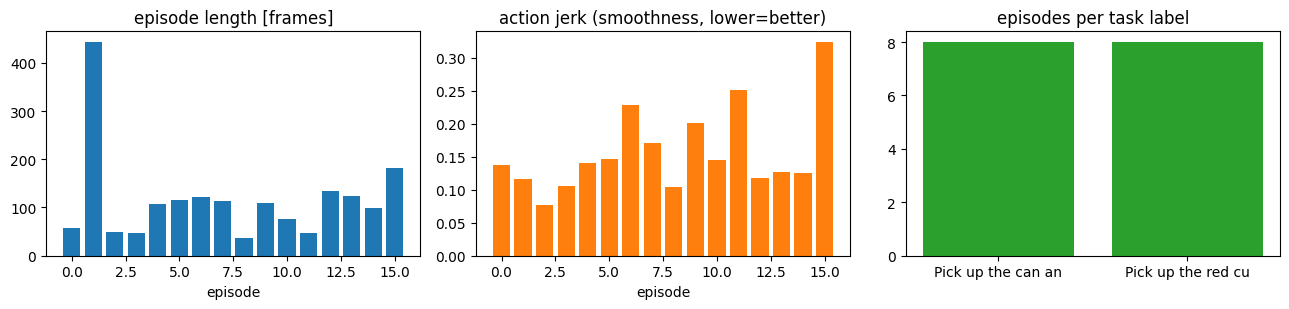

問い: エピソード長と jerk(動きのガタつき)で浮かび上がる bag はどれですか?


In [ ]:
# セル 3-3(与えるコード): 全 16 本の統計ダッシュボード
# ここからは checkpoint の変換済み 16 本データセットを使います(遅延ダウンロード)
from lerobot.datasets.lerobot_dataset import LeRobotDataset

ds16 = LeRobotDataset(repo_id="pai2026/lecture6-bags16",
                      root=utils.DATA_DIR / "lerobot" / "lecture6-bags16")
utils.stats_report(ds16)
print("問い: エピソード長と jerk(動きのガタつき)で浮かび上がる bag はどれですか?")

### 気づいたことをメモ

> 統計で浮かび上がったエピソード: ____(理由: 長さ / jerk / その他)

*(このあと Step 4 の判断表に書き写します)*

## Step 4a: Curate — 判断表を書く(3 分 + 随時)

*講義スライド「データキュレーション」対応*

ここまでの発見を**判断表**にまとめます。処置は 3 種類です:

| 処置 | 意味 | 使いどころ |
|---|---|---|
| keep | そのまま納品 | 問題なし |
| filter | 除外して納品 | 直せない汚れ(同期不能・欠落・低品質) |
| relabel | ラベルを直して納品 | **データ自体は良いのにラベルだけ違う**とき |

**考えどころ**: 「成功しているけど下手」なテイクは keep か filter か——正解は一意ではありません。**根拠を書けること**が今日の評価軸です。

In [ ]:
# セル 4-1(与えるコード): 判断表の雛形
import pandas as pd

bag_names = [b.name for b in utils.list_bags()]
df = pd.DataFrame({
    "episode_id": range(len(bag_names)),
    "bag": bag_names,
    "decision": "keep",          # keep / filter / relabel に書き換える
    "method": "",                # 検出方法(レイテンシ / max Δt / jerk / 目視 / kNN など)
    "reason": "",                # 根拠(単位付きの数値があると強い)
    "new_task": "",              # relabel のときだけ: lift か can
})
# 例: Step 1 で見つけたレイテンシ異常 bag(自分の結果に合わせて書き換えてください)
# df.loc[6, ["decision", "method", "reason"]] = ["filter", "latency", "joint stamp +348ms"]
df

,episode_id,bag,decision,method,reason,new_task
0,0,ep_000,keep,,,
1,1,ep_001,keep,,,
2,2,ep_002,keep,,,
3,3,ep_003,keep,,,
4,4,ep_004,keep,,,
5,5,ep_005,keep,,,
6,6,ep_006,keep,,,
7,7,ep_007,keep,,,
8,8,ep_008,keep,,,
9,9,ep_009,keep,,,


### 作業: 判断表を埋める

- Step 1(レイテンシ)・Step 2(相互相関)・Step 3(統計)の発見を行に書き込みます
- 迷った bag は `utils.episode_video(ds16, episode_id)` で**最終目視**してください
- 授業内は **1 行以上**書ければ OK です(残りは時間のあるときに)

In [ ]:
# セル 4-3(与えるコード): 判断表を適用して「納品物 1」を作る
# relabel は lerobot の dataset_tools.modify_tasks の薄いラッパーです(in-place なので
# 元データセットのコピーに対して適用します)
curated, keep_eps = utils.apply_curation(
    utils.DATA_DIR / "lerobot" / "lecture6-bags16", df, "my_dataset_curated")

filter: 0 本除外, relabel: 0 本, keep: 16 本


## Step 4b: 埋め込み kNN によるラベル監査 — 統計が正常でも、まだおかしい(講師デモ)

*講義スライド「指示ラベルの誤り」「古典的な道具はどこまで効くか」対応*

ここまでの検査(レイテンシ・ギャップ・長さ・jerk)を全部通り抜けたのに、**まだ 2 本おかしい** bag があります。数値統計もグラフも正常——おかしいのは「**指示ラベルと実際の行動の対応**」(指示ラベルの誤り、instruction label noise)です。

ここで実装するのは、講義で紹介した確立された 2 つの道具です:

- **Deep kNN** [Bahri+ ICML 2020]: 埋め込み空間で近傍のラベルを投票させ、自分のラベルと食い違う点を疑う
- **最近傍セントロイド(プロトタイプ)**: タスクごとの中心ベクトルとの距離で食い違いを疑う

今日は lift と can という**見た目で区別できる**タスクペアなので視覚埋め込みだけで見つかりますが、実データでは見た目が似たタスク間(棚に入れる/出す等)で起きます。多視点のどれを信じるか・モダリティが死んだらどうするかは、講義で話したとおり**ロボットではほぼ未開拓の research problem** です。まず道具を自分の手で動かしてください。

エピソード: 16 / ラベル内訳: {np.str_('can'): np.int64(8), np.str_('lift'): np.int64(8)}
kNN 対象: 16 本(filter 済みを除外)


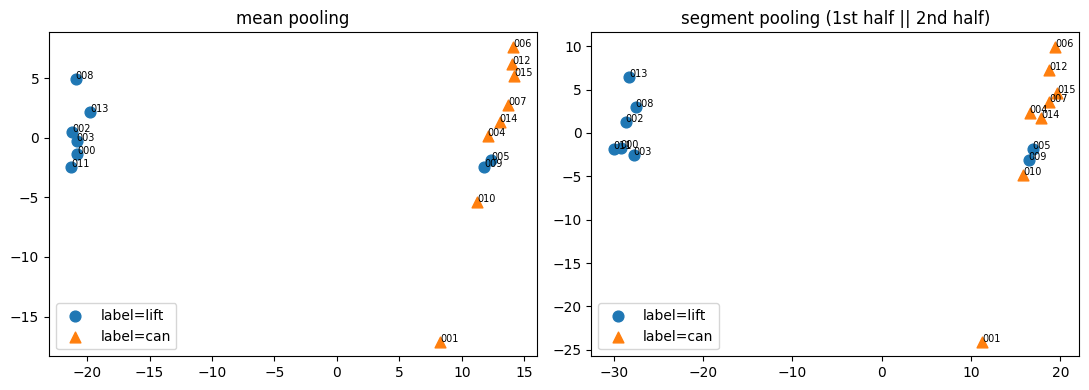

右図で、lift ラベルなのに can 側に混ざる点はありませんか?


In [ ]:
# セル 4-5(与えるコード): 事前計算済み埋め込みのロードと「順序を残すプーリング」
# vis_frames: 各エピソード 16 フレームの DINOv2 特徴(384 次元)
emb = dict(np.load(utils.DATA_DIR / "checkpoints" / "embeddings.npz", allow_pickle=True))
ep_ids, labels = emb["ep_ids"].astype(str), emb["labels"].astype(str)
print("エピソード:", len(ep_ids), "/ ラベル内訳:", dict(zip(*np.unique(labels, return_counts=True))))

# 判断表で filter にしたものは除外(キュレーションが下流工程を守る、の実例)
filtered_bags = set(df[df.decision == "filter"].bag)
keep = np.array([e not in filtered_bags for e in ep_ids])
print("kNN 対象:", int(keep.sum()), "本(filter 済みを除外)")

# 平均プーリング vs セグメントプーリング(前半‖後半)の対比
# 平均は「時間順序」を捨てるので、往路と復路が同じ点に潰れます
mean_pool = emb["vis_frames"].mean(1)
seg_pool = utils.segment_pool(emb["vis_frames"])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feats, title in [(axes[0], mean_pool, "mean pooling"),
                         (axes[1], seg_pool, "segment pooling (1st half || 2nd half)")]:
    x = utils.zscore(feats)
    # 2 次元へ射影(PCA 相当を SVD で)
    u, s, vt = np.linalg.svd(x - x.mean(0), full_matrices=False)
    p = u[:, :2] * s[:2]
    for lab, m in [("lift", "o"), ("can", "^")]:
        sel = labels == lab
        ax.scatter(p[sel, 0], p[sel, 1], marker=m, label=f"label={lab}", s=60)
    for i, e in enumerate(ep_ids):
        ax.annotate(e[-3:], (p[i, 0], p[i, 1]), fontsize=7)
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()
print("右図で、lift ラベルなのに can 側に混ざる点はありませんか?")

In [ ]:
# セル 4-6【TODO-5】: leave-one-out kNN 多数決で容疑者を挙げる
feats = utils.zscore(utils.segment_pool(emb["vis_frames"]))[keep]
ids_k, labels_k = ep_ids[keep], labels[keep]

def knn_vote(D, labels, k=5):
    """距離行列 D から leave-one-out kNN 多数決の予測ラベルを返す。"""
    # ---- TODO ここから(5 行):
    D = D.copy()
    np.fill_diagonal(D, np.inf)          # 自分自身を近傍に入れない(leave-one-out)
    pred = []
    for i in range(len(labels)):
        nn = labels[np.argsort(D[i])[:k]]              # 近い k 本のラベル
        vals, counts = np.unique(nn, return_counts=True)
        pred.append(vals[np.argmax(counts)])           # 多数決
    # ---- TODO ここまで
    return np.asarray(pred)

D = np.linalg.norm(feats[:, None] - feats[None, :], axis=2)
pred = knn_vote(D, labels_k, k=5)
suspects = [str(e) for e in ids_k[pred != labels_k]]
print("kNN 予測と付与ラベルの不一致(=容疑者):", suspects)
utils.check_labels(suspects)

kNN 予測と付与ラベルの不一致(=容疑者): ['ep_005', 'ep_009']
✅ 容疑者数: 2 本: ['ep_005', 'ep_009']（期待: ちょうど 2 本）
→ この 2 本を mp4 で目視して、指示文と本当に食い違うか確認しましょう。


In [ ]:
#@title ▶ 解答 5(詰まったら開いて実行してください) { display-mode: "form" }
feats = utils.zscore(utils.segment_pool(emb["vis_frames"]))[keep]
ids_k, labels_k = ep_ids[keep], labels[keep]

def knn_vote(D, labels, k=5):
    D = D.copy()
    np.fill_diagonal(D, np.inf)
    pred = []
    for i in range(len(labels)):
        nn = labels[np.argsort(D[i])[:k]]
        vals, counts = np.unique(nn, return_counts=True)
        pred.append(vals[np.argmax(counts)])
    return np.asarray(pred)

D = np.linalg.norm(feats[:, None] - feats[None, :], axis=2)
pred = knn_vote(D, labels_k, k=5)
suspects = [str(e) for e in ids_k[pred != labels_k]]
print("容疑者:", suspects)
utils.check_labels(suspects)

容疑者: ['ep_005', 'ep_009']
✅ 容疑者数: 2 本: ['ep_005', 'ep_009']（期待: ちょうど 2 本）
→ この 2 本を mp4 で目視して、指示文と本当に食い違うか確認しましょう。


In [ ]:
#@title (発展・読むだけでOK) 2 モダリティの多数決と「要目視」運用 { display-mode: "form" }
# 視覚だけでなく関節軌道(64 ステップ × 7 関節)でも同じ Deep kNN を回します。
# 両方が容疑者と言う bag は自信を持って容疑者に、票が割れた bag は「要目視」に回す——
# という運用です。「どのモダリティを信じるか」は講義で話した未解決問題で、
# ここでは最も素朴な解(多数決 + 人間へのエスカレーション)を体験します。
# さらに進めたい人へ: Confident Learning [Northcutt+ JAIR 2021](pip install cleanlab)を
# 同じ埋め込み + 軽量分類器に適用して、kNN の検出結果と比較してみてください。
feats_j = utils.zscore(emb["joint"])[keep]
Dj = np.linalg.norm(feats_j[:, None] - feats_j[None, :], axis=2)
suspects_j = {str(s) for s in ids_k[knn_vote(Dj, labels_k, k=5) != labels_k]}
both = sorted(set(suspects) & suspects_j)
split = sorted(set(suspects) ^ suspects_j)
print("関節モダリティの容疑者:", sorted(suspects_j))
print("両モダリティが一致した容疑者:", both)
print("票が割れた(=要目視に回す)bag:", split if split else "なし")

関節モダリティの容疑者: ['ep_001', 'ep_005', 'ep_009']
両モダリティが一致した容疑者: ['ep_005', 'ep_009']
票が割れた(=要目視に回す)bag: ['ep_001']


In [ ]:
# セル 4-8: 容疑者を目視 → relabel
# (1) 容疑者の動画と指示文を並べて確認します
import json
instr = json.loads((utils.DATA_DIR / "bags" / "collection_log.json").read_text())
name = suspects[0]                       # 2 本目は suspects[1] に変えて再実行
ep_id = [b.name for b in utils.list_bags()].index(name)
print(f"{name} の指示文:「{instr[name]['instruction']}」← 映像と合っていますか?")
utils.episode_video(ds16, ep_id)

ep_005 の指示文:「Pick up the red cube and lift it.」← 映像と合っていますか?


In [ ]:
# (2) 判断表を relabel で更新して、キュレーション済みデータセットを完成させます
for name in suspects:
    ep_id = [b.name for b in utils.list_bags()].index(name)
    df.loc[ep_id, ["decision", "method", "new_task"]] = ["relabel", "kNN+目視", "can"]
    df.loc[ep_id, "reason"] = "映像は can のピック&プレース、指示文は lift"

curated, keep_eps = utils.apply_curation(
    utils.DATA_DIR / "lerobot" / "lecture6-bags16", df, "my_dataset_curated")
df   # 完成した判断表を眺めて、根拠が言えるか確認してください

Updating episodes: 100%|██████████| 1/1 [00:00<00:00, 34.80it/s]


filter: 0 本除外, relabel: 2 本, keep: 16 本


,episode_id,bag,decision,method,reason,new_task
0,0,ep_000,keep,,,
1,1,ep_001,keep,,,
2,2,ep_002,keep,,,
3,3,ep_003,keep,,,
4,4,ep_004,keep,,,
5,5,ep_005,relabel,kNN+目視,映像は can のピック&プレース、指示文は lift,can
6,6,ep_006,keep,,,
7,7,ep_007,keep,,,
8,8,ep_008,keep,,,
9,9,ep_009,relabel,kNN+目視,映像は can のピック&プレース、指示文は lift,can


## Step 5: 学習比較 — 納品物の答え合わせ(4 分・閲覧中心)

*講義スライド「データ品質と方策性能」対応*

同じ方策(ACT)・同じ学習規模(200k step)で、**データだけ**を変えて学習した 3 つのチェックポイントを用意しました(can タスク、フル規模データで事前学習済み):

1. **①同期ずれを放置**: D1 と同じ +350 ms のずれが入ったまま学習(300 本)
2. **②同期を修正**: 時刻同期だけ直した。「下手だが成功」の worse テイク 100 本は残っている(300 本)
3. **③worse も filter**: 同期修正に加えて worse を除外(ph のみ 200 本)

見どころは 2 つあります。

- ①の学習曲線——**loss は普通に下がります**。「学習が回ること」と「ロボットが動くこと」は別物です
- **②と③の順位**。「下手なデータは捨てるべき」という直感は、この規模では**実測に裏切られます**(捨てた分だけデータ量とカバレッジが痩せる——講義で話した filter の副作用そのものです)

,name,description,n_episodes,n_rollouts,success_rate
0,cond1_dirty,① 同期ずれ(+350ms)を放置,300,50,0.22
1,cond2_sync,② 同期を修正(worse 込み 300 本),300,50,0.88
2,cond3_curated,③ 同期修正 + worse を filter(200 本),200,50,0.54


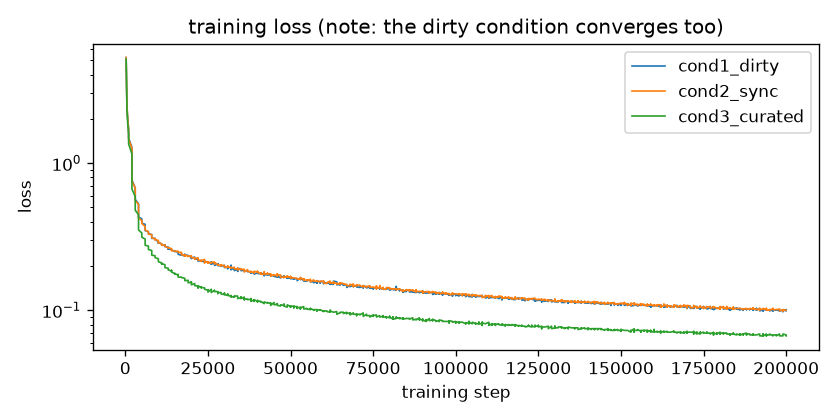

step5_cond1_dirty.mp4


step5_cond2_sync.mp4


In [ ]:
# セル 5-1(与えるコード): 条件別の成功率と rollout 動画(事前計算)
import json
from pathlib import Path
from IPython.display import Video, display

res_path = utils.DATA_DIR / "checkpoints" / "step5_results.json"
if res_path.exists():
    res = json.loads(res_path.read_text())
    import pandas as pd
    tbl = pd.DataFrame(res["conditions"])
    display(tbl[["name", "description", "n_episodes", "n_rollouts", "success_rate"]])
    # 学習曲線(①でも loss は下がる、を見る)
    from IPython.display import Image as IPImage
    curve = utils.DATA_DIR / "checkpoints" / "step5_loss_curves.png"
    if curve.exists():
        display(IPImage(str(curve)))
    for mp4 in sorted((utils.DATA_DIR / "checkpoints").glob("step5_*.mp4"))[:2]:
        print(mp4.name)
        display(Video(str(mp4), embed=True, width=400))
else:
    print("(事前計算結果は前日までに配布データに追加されます)")

In [ ]:
#@title (任意・時間があれば) 最良条件②のチェックポイントでライブ rollout 1 本 { display-mode: "form" }
# CPU で 1〜2 分かかります。混雑時はスキップしてください(上の動画と同じものが動きます)。
try:
    utils.fetch_data(["checkpoints/act_best/*"])   # 約 198 MB(初回のみ)
    ckpt = utils.DATA_DIR / "checkpoints" / "act_best"
    if not ckpt.exists():
        print("チェックポイント未配布のためスキップします")
    else:
        import mujoco  # noqa: F401
        print("rollout を開始します…(数分)")
        # 実装は配布 utils_rollout.py(robosuite を直接起動します)
        import utils_rollout
        utils_rollout.rollout_once(ckpt)
except Exception as e:
    import traceback
    print(f"この環境ではライブ rollout をスキップします({e})")
    traceback.print_exc()   # GL 設定ミス等の原因を当日 TA が追えるように

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

rollout を開始します…(数分)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Loading weights from local directory


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


rollout 1/1: 成功

成功率: 1/1 = 100%


### 議論(講師と一緒に)

- **①(同期放置)と②(同期修正)の差**: 350 ms のずれは方策をどれだけ壊しましたか? 発展課題のミニ実験(0/100/200 ms)の用量反応と合わせて、「どこまでのずれなら許容か」を自分の言葉で説明してみてください
- **②(worse 込み 300 本)と③(worse を捨てた 200 本)の差**: 「低品質は捨てるべき」の直感と逆でしたね。判断表で D3 を filter にした人は間違いだったのでしょうか?——**いいえ**。lift の小規模実験では worse は無害、can のこの規模では捨てると大損。つまり**処置の正しさはタスク・規模・方策に依存します**。「捨てる前に副作用を測る」が今日持ち帰る原則です(講義の Filtering vs Relabeling の議論)
- relabel(指示ラベル誤りの 2 本)は今日の ACT の成功率には効いていません。**なぜでしょう?**(ヒント: 今日の ACT は言語指示を入力に使っていません。どんな方策なら relabel が効きますか?)

## Step 6(発展ミニ実験): 同期ずれは何 ms から方策を壊すのか

*自分の手で「データ品質 → 成功率」を1本つなげる実験です(所要 15〜20 分)*

Step 5 は講師が事前学習した結果でした。ここでは**自分で学習して**確かめます。ただし丸ごとは重いので、最小構成にしてあります:

- タスクは lift(約 2.5 秒)、デモ 20 本固定、画像 96×96、小型 ACT、5000 step
- **品質ノブは 1 つだけ**:「全エピソードの観測と行動を何 ms ずらすか」∈ {0, 100, 200} ms
- データセットは各 1 MB。学習は **Colab の GPU ランタイム(T4)で約 10〜12 分**です
  (ここだけ本編と違い GPU が必要です。ランタイム → ランタイムのタイプを変更 → T4 GPU)

> ⚠️ **ランタイムタイプを変更すると環境が初期化されます**(VM 入れ替え。pip もパッチも消えます)。
> T4 に切り替えたら **セル 0-1, 0-2 を再実行してから** 6-1 に進んでください(pip に 1 分ほど)。
> 「ランタイム → セッションを再起動」はファイルが残るので再インストール不要です。
>
> **止まったときの復旧**: ①ランタイム→セッションを再起動 ②0-1, 0-2 を再実行
> ③0-2 の `import lerobot.policies` が通るのを確認 ④6-1 へ。

3 条件のうち **1 つを選んで**学習・評価し、講師の実測カーブと突き合わせてください。

| ずれ | 0 ms | 100 ms | 200 ms |
|---|---|---|---|
| 講師の実測(5000 step・**各 100 rollouts**) | 80% | 74% | 56% |

200 ms の劣化は統計的に有意(p<0.001)、100 ms は傾向のみ(有意差なし)です。あなたの 10 rollouts は 1 点の観測としてはノイジーなので、クラス全体で持ち寄ると層が見えてきます。

In [ ]:
# セル 6-1: 条件を選んで学習(T4で5000stepsで約3時間。checkpoint があればスキップ)
SHIFT_MS = 0  #@param [0, 100, 200] {type:"raw"}

import torch
assert torch.cuda.is_available(),     "GPU ランタイムに切り替えてください(ランタイム→ランタイムのタイプを変更→T4 GPU)。"     "切替後は 0-1, 0-2 を再実行してからここへ。"

from pathlib import Path
name = f"lift-sync{SHIFT_MS:03d}ms"
utils.fetch_data([f"lerobot/{name}/*"])              # 学習データ 約 1 MB
ckpt = Path(f"mini_train_{name}/checkpoints/last/pretrained_model")

if ckpt.exists():
    print(f"学習済み checkpoint があります: {ckpt}")
elif not (utils.DATA_DIR / "lerobot" / name).exists():
    print(f"データセット {name} が見つかりません。セル 0-2 を再実行してください。")
else:
    # 受講生が回すのと同じ小型 ACT 設定(講師実測: T4 相当で 5000 step ≈ 10 分)
    args = " ".join([
        f"--dataset.repo_id=pai2026/{name}",
        f"--dataset.root={utils.DATA_DIR}/lerobot/{name}",
        "--policy.type=act", "--policy.chunk_size=20", "--policy.n_action_steps=20",
        "--policy.dim_model=256", "--policy.n_encoder_layers=2", "--policy.n_decoder_layers=1",
        "--policy.dim_feedforward=1024", "--policy.device=cuda", "--policy.push_to_hub=false",
        "--steps=1000", "--batch_size=16", "--num_workers=2", "--log_freq=500", "--save_freq=5000",
        f"--output_dir=mini_train_{name}", "--wandb.enable=false",
    ])
    import subprocess
    ret = subprocess.run(f"lerobot-train {args}", shell=True)
    # !lerobot-train はシェル実行なので失敗してもセルは正常終了に見える。明示的に検知する。
    if ret.returncode != 0:
        raise RuntimeError(
            f"lerobot-train が失敗しました(exit {ret.returncode})。上のログを確認してください。"
            "多くは 0-2 の import で気付けます。ダメならセッション再起動→0-1 から。"
        )

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

学習済み checkpoint があります: mini_train_lift-sync000ms/checkpoints/last/pretrained_model


In [ ]:
# セル 6-2: 評価(10 rollouts、数分)— 自分の学習した方策 or 講師の checkpoint
from pathlib import Path
import utils_rollout

name = f"lift-sync{SHIFT_MS:03d}ms"
ckpt = Path(f"mini_train_{name}/checkpoints/last/pretrained_model")
if not ckpt.exists():
    utils.fetch_data([f"checkpoints/mini/{name}/*"])   # 講師の学習済み 約 65 MB(初回のみ)
    ckpt = utils.DATA_DIR / "checkpoints" / "mini" / name
    print(f"(自分の checkpoint がないので講師の学習済みを使います: {ckpt})")

rate = utils_rollout.rollout(ckpt, task="lift", n=10)
print()
print(f"あなたの条件: ずれ {SHIFT_MS} ms → 成功率 {rate:.0%}")
print("講師の実測カーブ(80% / 74% / 56%)と比べてどうでしたか?")

Loading weights from local directory


/content/utils_rollout.py:100: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  "observation.images.agentview": torch.from_numpy(frames["agentview"]).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0,


rollout 1/10: 成功
rollout 2/10: 成功
rollout 3/10: 失敗
rollout 4/10: 成功
rollout 5/10: 成功
rollout 6/10: 成功
rollout 7/10: 成功
rollout 8/10: 成功
rollout 9/10: 成功
rollout 10/10: 成功

成功率: 9/10 = 90%



あなたの条件: ずれ 0 ms → 成功率 90%
講師の実測カーブ(80% / 74% / 56%)と比べてどうでしたか?


### 記入欄

> ずれ ____ ms を担当。成功率 ____%(10 rollouts)。講師カーブとの差: ____
> 気づき(例: 100 ms は Step 1 で見たカメラ伝送遅延と同じオーダー):

**考える問い**: この実験で 200 ms のずれは成功率を約 24 pt 下げました(100 ms は約 6 pt で誤差の範囲)。Step 1 で測ったレイテンシや Step 2 の slop と突き合わせると、あなたのロボットの記録系にはどこまでのずれなら許容できそうですか?

## さらに遊びたい人へ(発展・提出はありません)

- **まず Step 6 のミニ実験**(上)を 1 条件やってみてください。友人と条件を分担して 3 点カーブを埋めるのも歓迎です
- **自分のルールでフルデータをキュレーションして再学習**: 今日の 16 本はミニチュアでした。フル規模データ(can タスク ph 200 本 + マルチヒューマン 300 本、変換済みで配布)に、自分の判断ルール(長さ・jerk・レイテンシの閾値)をプログラムで適用 → ACT を再学習 → 評価。講師の②(88%)を超えられるでしょうか
- D1 の bag をオフセット推定で「救って」再同期し、学習データに加えると成功率は上がるでしょうか
- マルチヒューマンデータの okay 層を入れる/外すの感度を調べてください(データ量と品質のトレードオフ)